<a href="https://colab.research.google.com/github/MohamedAhmedGalal/AI_fake_audios/blob/main/AI_gen_voice_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Sample 1 duration: 84.56707482993197
Sample 1 Residual Energy: 0.36027429
Sample 1 Cepstral Anomaly Score: 7.5922437


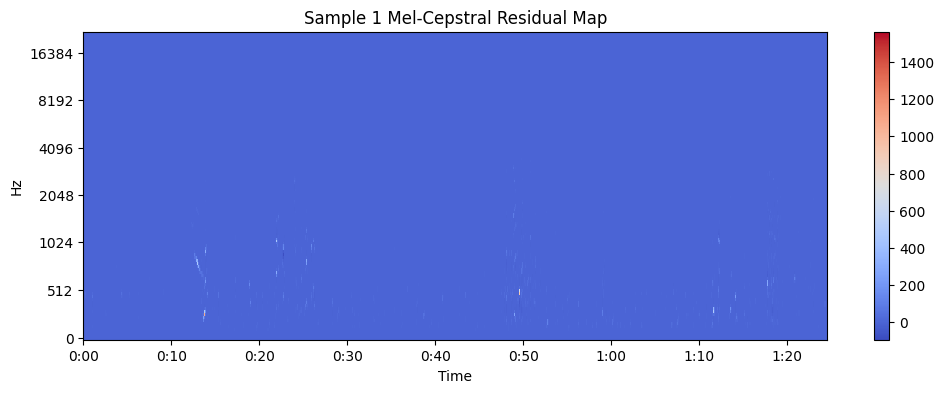

In [3]:
# ============================================
# SAMPLE 1 : MEL-CEPSTRAL RESIDUAL ANALYSIS
# ============================================

!pip install librosa --quiet

import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------
# Load audio
# --------------------------------
sample1_audio_path = "/content/sample.mp3"

sample1_signal, sample1_sr = librosa.load(sample1_audio_path, sr=None)

print("Sample 1 duration:", len(sample1_signal)/sample1_sr)

# --------------------------------
# Compute Mel Spectrogram
# --------------------------------
sample1_mel_spec = librosa.feature.melspectrogram(
    y=sample1_signal,
    sr=sample1_sr,
    n_mels=128
)

sample1_mel_db = librosa.power_to_db(sample1_mel_spec)

# --------------------------------
# Compute MFCC
# --------------------------------
sample1_mfcc = librosa.feature.mfcc(
    S=sample1_mel_db,
    n_mfcc=20
)

# --------------------------------
# Reconstruct Mel spectrum from MFCC
# --------------------------------
sample1_reconstructed = librosa.feature.inverse.mfcc_to_mel(
    sample1_mfcc,
    n_mels=128
)

# --------------------------------
# Residual (difference)
# --------------------------------
sample1_residual = sample1_mel_spec - sample1_reconstructed

sample1_residual_energy = np.mean(np.abs(sample1_residual))

print("Sample 1 Residual Energy:", sample1_residual_energy)

# --------------------------------
# Residual anomaly score
# --------------------------------
sample1_residual_std = np.std(sample1_residual)

sample1_anomaly_score = sample1_residual_std

print("Sample 1 Cepstral Anomaly Score:", sample1_anomaly_score)

# --------------------------------
# Visualization
# --------------------------------
plt.figure(figsize=(12,4))
librosa.display.specshow(
    sample1_residual,
    sr=sample1_sr,
    x_axis="time",
    y_axis="mel"
)
plt.colorbar()
plt.title("Sample 1 Mel-Cepstral Residual Map")
plt.show()

Sample 2 duration: 60.46476190476191
Sample 2 Residual Energy: 0.47719157
Sample 2 Cepstral Anomaly Score: 4.7373314


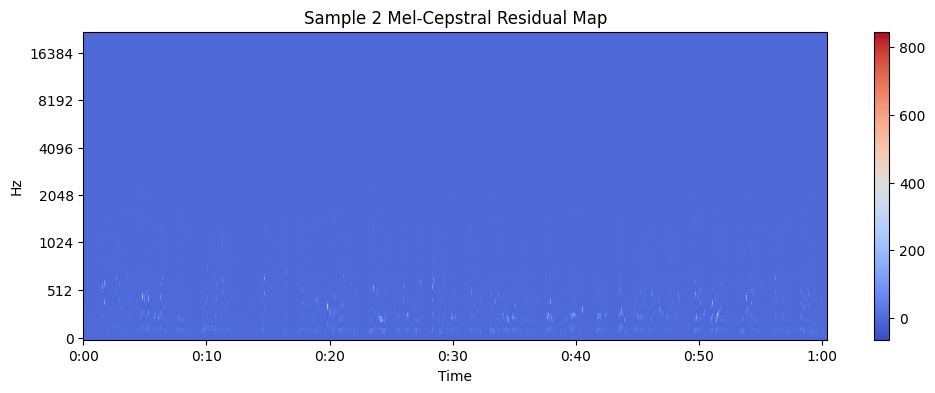

In [4]:
# ============================================
# SAMPLE 2 : MEL-CEPSTRAL RESIDUAL ANALYSIS
# ============================================

!pip install librosa --quiet

import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------
# Load audio
# --------------------------------
sample2_audio_path = "/content/sample_2.mp3"

sample2_signal, sample2_sr = librosa.load(sample2_audio_path, sr=None)

print("Sample 2 duration:", len(sample2_signal)/sample2_sr)

# --------------------------------
# Compute Mel Spectrogram
# --------------------------------
sample2_mel_spec = librosa.feature.melspectrogram(
    y=sample2_signal,
    sr=sample2_sr,
    n_mels=128
)

sample2_mel_db = librosa.power_to_db(sample2_mel_spec)

# --------------------------------
# Compute MFCC
# --------------------------------
sample2_mfcc = librosa.feature.mfcc(
    S=sample2_mel_db,
    n_mfcc=20
)

# --------------------------------
# Reconstruct Mel spectrum
# --------------------------------
sample2_reconstructed = librosa.feature.inverse.mfcc_to_mel(
    sample2_mfcc,
    n_mels=128
)

# --------------------------------
# Residual difference
# --------------------------------
sample2_residual = sample2_mel_spec - sample2_reconstructed

sample2_residual_energy = np.mean(np.abs(sample2_residual))

print("Sample 2 Residual Energy:", sample2_residual_energy)

# --------------------------------
# Cepstral anomaly score
# --------------------------------
sample2_residual_std = np.std(sample2_residual)

sample2_anomaly_score = sample2_residual_std

print("Sample 2 Cepstral Anomaly Score:", sample2_anomaly_score)

# --------------------------------
# Visualization
# --------------------------------
plt.figure(figsize=(12,4))
librosa.display.specshow(
    sample2_residual,
    sr=sample2_sr,
    x_axis="time",
    y_axis="mel"
)
plt.colorbar()
plt.title("Sample 2 Mel-Cepstral Residual Map")
plt.show()

Sample 1 duration: 84.56707482993197
Sample 1 Phase Coherence Score: 2.548856
Sample 1 Spectral Flatness: 0.00047189574
Sample 1 High-Frequency Energy Ratio: 0.046556216
Sample 1 Residual Kurtosis: 10893.885


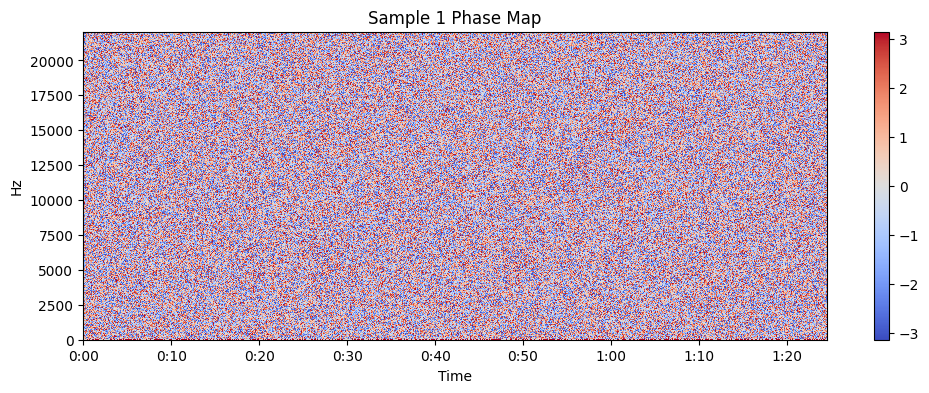

In [6]:
# ============================================
# SAMPLE 1 : ADVANCED AI DETECTION
# ============================================

import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kurtosis

# --------------------------------
# Load audio
# --------------------------------
sample1_audio_path = "/content/sample.mp3"  # <-- update path if needed
sample1_signal, sample1_sr = librosa.load(sample1_audio_path, sr=None)
print("Sample 1 duration:", len(sample1_signal)/sample1_sr)

# --------------------------------
# Short-Time Fourier Transform
# --------------------------------
sample1_stft = librosa.stft(sample1_signal, n_fft=2048, hop_length=512)
sample1_mag, sample1_phase = np.abs(sample1_stft), np.angle(sample1_stft)

# --------------------------------
# Phase Coherence Metric
# --------------------------------
sample1_phase_diff = np.diff(sample1_phase, axis=1)
sample1_phase_coherence = np.mean(np.abs(np.std(sample1_phase_diff, axis=1)))
print("Sample 1 Phase Coherence Score:", sample1_phase_coherence)

# --------------------------------
# Spectral Flatness / Tonality
# --------------------------------
sample1_flatness = np.mean(librosa.feature.spectral_flatness(y=sample1_signal))
print("Sample 1 Spectral Flatness:", sample1_flatness)

# --------------------------------
# High-Frequency Energy Ratio
# --------------------------------
sample1_fft = np.fft.rfft(sample1_signal)
sample1_freqs = np.fft.rfftfreq(len(sample1_signal), d=1/sample1_sr)
sample1_high_energy_ratio = np.sum(np.abs(sample1_fft[sample1_freqs>8000])) / np.sum(np.abs(sample1_fft))
print("Sample 1 High-Frequency Energy Ratio:", sample1_high_energy_ratio)

# --------------------------------
# Residual Kurtosis
# --------------------------------
sample1_mel_spec = librosa.feature.melspectrogram(y=sample1_signal, sr=sample1_sr, n_mels=128)
sample1_mel_db = librosa.power_to_db(sample1_mel_spec)
sample1_mfcc = librosa.feature.mfcc(S=sample1_mel_db, n_mfcc=20)
sample1_reconstructed = librosa.feature.inverse.mfcc_to_mel(sample1_mfcc, n_mels=128)
sample1_residual = sample1_mel_spec - sample1_reconstructed
sample1_residual_kurtosis = kurtosis(sample1_residual.flatten())
print("Sample 1 Residual Kurtosis:", sample1_residual_kurtosis)

# --------------------------------
# Visualization of Phase Coherence
# --------------------------------
plt.figure(figsize=(12,4))
librosa.display.specshow(sample1_phase, sr=sample1_sr, x_axis='time', y_axis='hz')
plt.colorbar()
plt.title("Sample 1 Phase Map")
plt.show()

Sample 2 duration: 60.46476190476191
Sample 2 Phase Coherence Score: 2.5469346
Sample 2 Spectral Flatness: 0.0037363418
Sample 2 High-Frequency Energy Ratio: 0.019586932
Sample 2 Residual Kurtosis: 3726.253


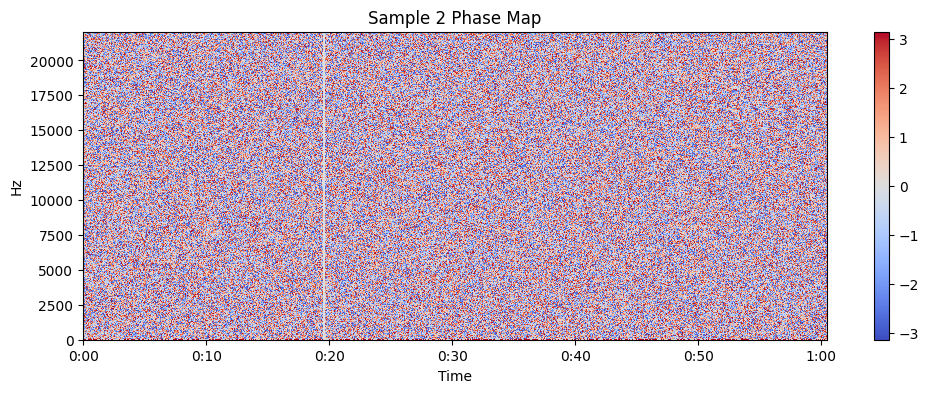

In [5]:
# ============================================
# SAMPLE 2 : ADVANCED AI DETECTION
# ============================================

import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kurtosis

# --------------------------------
# Load audio
# --------------------------------
sample2_audio_path = "/content/sample_2.mp3"
sample2_signal, sample2_sr = librosa.load(sample2_audio_path, sr=None)
print("Sample 2 duration:", len(sample2_signal)/sample2_sr)

# --------------------------------
# Short-Time Fourier Transform
# --------------------------------
sample2_stft = librosa.stft(sample2_signal, n_fft=2048, hop_length=512)
sample2_mag, sample2_phase = np.abs(sample2_stft), np.angle(sample2_stft)

# --------------------------------
# Phase Coherence Metric
# --------------------------------
# Compute standard deviation of phase differences over time (lower -> smoother -> possibly AI)
sample2_phase_diff = np.diff(sample2_phase, axis=1)
sample2_phase_coherence = np.mean(np.abs(np.std(sample2_phase_diff, axis=1)))
print("Sample 2 Phase Coherence Score:", sample2_phase_coherence)

# --------------------------------
# Spectral Flatness / Tonality
# --------------------------------
sample2_flatness = np.mean(librosa.feature.spectral_flatness(y=sample2_signal))
print("Sample 2 Spectral Flatness:", sample2_flatness)

# --------------------------------
# High-Frequency Energy Ratio
# --------------------------------
# Ratio of energy above 8kHz / total energy
sample2_fft = np.fft.rfft(sample2_signal)
sample2_freqs = np.fft.rfftfreq(len(sample2_signal), d=1/sample2_sr)
sample2_high_energy_ratio = np.sum(np.abs(sample2_fft[sample2_freqs>8000])) / np.sum(np.abs(sample2_fft))
print("Sample 2 High-Frequency Energy Ratio:", sample2_high_energy_ratio)

# --------------------------------
# Kurtosis (spikiness) of residual
# --------------------------------
sample2_mel_spec = librosa.feature.melspectrogram(y=sample2_signal, sr=sample2_sr, n_mels=128)
sample2_mel_db = librosa.power_to_db(sample2_mel_spec)
sample2_mfcc = librosa.feature.mfcc(S=sample2_mel_db, n_mfcc=20)
sample2_reconstructed = librosa.feature.inverse.mfcc_to_mel(sample2_mfcc, n_mels=128)
sample2_residual = sample2_mel_spec - sample2_reconstructed
sample2_residual_kurtosis = kurtosis(sample2_residual.flatten())
print("Sample 2 Residual Kurtosis:", sample2_residual_kurtosis)

# --------------------------------
# Visualization of Phase Coherence
# --------------------------------
plt.figure(figsize=(12,4))
librosa.display.specshow(sample2_phase, sr=sample2_sr, x_axis='time', y_axis='hz')
plt.colorbar()
plt.title("Sample 2 Phase Map")
plt.show()

In [7]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kurtosis

# =====================================
# BASELINE SAMPLE (Known Human)
# =====================================
baseline_path = "/content/sample_1.mp3"  # <-- update path
baseline_signal, baseline_sr = librosa.load(baseline_path, sr=None)

# Phase coherence
baseline_stft = librosa.stft(baseline_signal, n_fft=2048, hop_length=512)
baseline_phase = np.angle(baseline_stft)
baseline_phase_diff = np.diff(baseline_phase, axis=1)
baseline_phase_coherence = np.mean(np.abs(np.std(baseline_phase_diff, axis=1)))

# Spectral flatness
baseline_flatness = np.mean(librosa.feature.spectral_flatness(y=baseline_signal))

# High-frequency energy
baseline_fft = np.fft.rfft(baseline_signal)
baseline_freqs = np.fft.rfftfreq(len(baseline_signal), d=1/baseline_sr)
baseline_high_energy_ratio = np.sum(np.abs(baseline_fft[baseline_freqs>8000])) / np.sum(np.abs(baseline_fft))

# Residual kurtosis
baseline_mel_spec = librosa.feature.melspectrogram(y=baseline_signal, sr=baseline_sr, n_mels=128)
baseline_mel_db = librosa.power_to_db(baseline_mel_spec)
baseline_mfcc = librosa.feature.mfcc(S=baseline_mel_db, n_mfcc=20)
baseline_reconstructed = librosa.feature.inverse.mfcc_to_mel(baseline_mfcc, n_mels=128)
baseline_residual = baseline_mel_spec - baseline_reconstructed
baseline_residual_kurtosis = kurtosis(baseline_residual.flatten())

print("=== Baseline Metrics (Human) ===")
print("Phase Coherence:", baseline_phase_coherence)
print("Spectral Flatness:", baseline_flatness)
print("High-Frequency Energy Ratio:", baseline_high_energy_ratio)
print("Residual Kurtosis:", baseline_residual_kurtosis)

# =====================================
# TEST SAMPLE (Unknown / Under Analysis)
# =====================================
test_path = "/content/sample_2.mp3"  # <-- update path
test_signal, test_sr = librosa.load(test_path, sr=None)

# Phase coherence
test_stft = librosa.stft(test_signal, n_fft=2048, hop_length=512)
test_phase = np.angle(test_stft)
test_phase_diff = np.diff(test_phase, axis=1)
test_phase_coherence = np.mean(np.abs(np.std(test_phase_diff, axis=1)))

# Spectral flatness
test_flatness = np.mean(librosa.feature.spectral_flatness(y=test_signal))

# High-frequency energy
test_fft = np.fft.rfft(test_signal)
test_freqs = np.fft.rfftfreq(len(test_signal), d=1/test_sr)
test_high_energy_ratio = np.sum(np.abs(test_fft[test_freqs>8000])) / np.sum(np.abs(test_fft))

# Residual kurtosis
test_mel_spec = librosa.feature.melspectrogram(y=test_signal, sr=test_sr, n_mels=128)
test_mel_db = librosa.power_to_db(test_mel_spec)
test_mfcc = librosa.feature.mfcc(S=test_mel_db, n_mfcc=20)
test_reconstructed = librosa.feature.inverse.mfcc_to_mel(test_mfcc, n_mels=128)
test_residual = test_mel_spec - test_reconstructed
test_residual_kurtosis = kurtosis(test_residual.flatten())

print("\n=== Test Sample Metrics ===")
print("Phase Coherence:", test_phase_coherence)
print("Spectral Flatness:", test_flatness)
print("High-Frequency Energy Ratio:", test_high_energy_ratio)
print("Residual Kurtosis:", test_residual_kurtosis)

# =====================================
# Relative Comparison & AI Likelihood
# =====================================
def relative_deviation(baseline, test):
    return abs(test - baseline) / (baseline + 1e-9)  # avoid division by zero

phase_dev = relative_deviation(baseline_phase_coherence, test_phase_coherence)
flatness_dev = relative_deviation(baseline_flatness, test_flatness)
highfreq_dev = relative_deviation(baseline_high_energy_ratio, test_high_energy_ratio)
kurtosis_dev = relative_deviation(baseline_residual_kurtosis, test_residual_kurtosis)

# Weighted AI likelihood (0-1)
# More deviation → higher likelihood of AI
ai_likelihood_score = (phase_dev + flatness_dev + highfreq_dev + kurtosis_dev) / 4

print("\n=== Relative Deviations ===")
print("Phase Coherence Deviation:", phase_dev)
print("Spectral Flatness Deviation:", flatness_dev)
print("High-Freq Energy Deviation:", highfreq_dev)
print("Residual Kurtosis Deviation:", kurtosis_dev)
print("\nEstimated AI Likelihood (0=Human, 1=AI):", ai_likelihood_score)

# Optional: interpret the score
if ai_likelihood_score < 0.2:
    verdict = "Likely Human"
elif ai_likelihood_score < 0.5:
    verdict = "Possibly Human / Ambiguous"
else:
    verdict = "Possibly AI-Generated"

print("Verdict:", verdict)

=== Baseline Metrics (Human) ===
Phase Coherence: 2.5439067
Spectral Flatness: 0.00040323666
High-Frequency Energy Ratio: 0.031479433
Residual Kurtosis: 2339.9028

=== Test Sample Metrics ===
Phase Coherence: 2.5469346
Spectral Flatness: 0.0037363418
High-Frequency Energy Ratio: 0.019586932
Residual Kurtosis: 3726.253

=== Relative Deviations ===
Phase Coherence Deviation: 0.0011902621
Spectral Flatness Deviation: 8.265859
High-Freq Energy Deviation: 0.3777864
Residual Kurtosis Deviation: 0.5924819

Estimated AI Likelihood (0=Human, 1=AI): 2.3093293
Verdict: Possibly AI-Generated


In [8]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kurtosis

# =====================================
# BASELINE SAMPLE (Known Human)
# =====================================
baseline_path = "/content/sample_1.mp3"  # <-- known human
baseline_signal, baseline_sr = librosa.load(baseline_path, sr=None)

# Phase coherence
baseline_stft = librosa.stft(baseline_signal, n_fft=2048, hop_length=512)
baseline_phase = np.angle(baseline_stft)
baseline_phase_diff = np.diff(baseline_phase, axis=1)
baseline_phase_coherence = np.mean(np.abs(np.std(baseline_phase_diff, axis=1)))

# Spectral flatness
baseline_flatness = np.mean(librosa.feature.spectral_flatness(y=baseline_signal))

# High-frequency energy
baseline_fft = np.fft.rfft(baseline_signal)
baseline_freqs = np.fft.rfftfreq(len(baseline_signal), d=1/baseline_sr)
baseline_high_energy_ratio = np.sum(np.abs(baseline_fft[baseline_freqs>8000])) / np.sum(np.abs(baseline_fft))

# Residual kurtosis
baseline_mel_spec = librosa.feature.melspectrogram(y=baseline_signal, sr=baseline_sr, n_mels=128)
baseline_mel_db = librosa.power_to_db(baseline_mel_spec)
baseline_mfcc = librosa.feature.mfcc(S=baseline_mel_db, n_mfcc=20)
baseline_reconstructed = librosa.feature.inverse.mfcc_to_mel(baseline_mfcc, n_mels=128)
baseline_residual = baseline_mel_spec - baseline_reconstructed
baseline_residual_kurtosis = kurtosis(baseline_residual.flatten())

print("=== Baseline Metrics (Human) ===")
print("Phase Coherence:", baseline_phase_coherence)
print("Spectral Flatness:", baseline_flatness)
print("High-Frequency Energy Ratio:", baseline_high_energy_ratio)
print("Residual Kurtosis:", baseline_residual_kurtosis)

# =====================================
# TEST SAMPLE (Unknown / Under Analysis)
# =====================================
test_path = "/content/sample_2.mp3"  # <-- test sample
test_signal, test_sr = librosa.load(test_path, sr=None)

# Phase coherence
test_stft = librosa.stft(test_signal, n_fft=2048, hop_length=512)
test_phase = np.angle(test_stft)
test_phase_diff = np.diff(test_phase, axis=1)
test_phase_coherence = np.mean(np.abs(np.std(test_phase_diff, axis=1)))

# Spectral flatness
test_flatness = np.mean(librosa.feature.spectral_flatness(y=test_signal))

# High-frequency energy
test_fft = np.fft.rfft(test_signal)
test_freqs = np.fft.rfftfreq(len(test_signal), d=1/test_sr)
test_high_energy_ratio = np.sum(np.abs(test_fft[test_freqs>8000])) / np.sum(np.abs(test_fft))

# Residual kurtosis
test_mel_spec = librosa.feature.melspectrogram(y=test_signal, sr=test_sr, n_mels=128)
test_mel_db = librosa.power_to_db(test_mel_spec)
test_mfcc = librosa.feature.mfcc(S=test_mel_db, n_mfcc=20)
test_reconstructed = librosa.feature.inverse.mfcc_to_mel(test_mfcc, n_mels=128)
test_residual = test_mel_spec - test_reconstructed
test_residual_kurtosis = kurtosis(test_residual.flatten())

print("\n=== Test Sample Metrics ===")
print("Phase Coherence:", test_phase_coherence)
print("Spectral Flatness:", test_flatness)
print("High-Frequency Energy Ratio:", test_high_energy_ratio)
print("Residual Kurtosis:", test_residual_kurtosis)

# =====================================
# Normalized Deviation & AI Likelihood
# =====================================
# Define approximate human ranges for normalization
human_ranges = {
    "phase": 5.0,        # typical phase coherence variation
    "flatness": 0.01,    # typical human spectral flatness
    "highfreq": 0.1,     # typical high-frequency energy ratio
    "kurtosis": 15000.0  # typical residual kurtosis
}

def normalized_deviation(baseline, test, max_range):
    # Absolute difference divided by expected human range, capped at 1
    return min(abs(test - baseline) / max_range, 1.0)

phase_dev = normalized_deviation(baseline_phase_coherence, test_phase_coherence, human_ranges["phase"])
flatness_dev = normalized_deviation(baseline_flatness, test_flatness, human_ranges["flatness"])
highfreq_dev = normalized_deviation(baseline_high_energy_ratio, test_high_energy_ratio, human_ranges["highfreq"])
kurtosis_dev = normalized_deviation(baseline_residual_kurtosis, test_residual_kurtosis, human_ranges["kurtosis"])

# Weighted AI likelihood (0-1)
ai_likelihood_score = (phase_dev + flatness_dev + highfreq_dev + kurtosis_dev) / 4

print("\n=== Normalized Deviations ===")
print("Phase Coherence Deviation:", phase_dev)
print("Spectral Flatness Deviation:", flatness_dev)
print("High-Freq Energy Deviation:", highfreq_dev)
print("Residual Kurtosis Deviation:", kurtosis_dev)
print("\nEstimated AI Likelihood (0=Human, 1=AI):", ai_likelihood_score)

# Interpret the score
if ai_likelihood_score < 0.2:
    verdict = "Likely Human"
elif ai_likelihood_score < 0.5:
    verdict = "Possibly Human / Ambiguous"
else:
    verdict = "Possibly AI-Generated"

print("Verdict:", verdict)

=== Baseline Metrics (Human) ===
Phase Coherence: 2.5439067
Spectral Flatness: 0.00040323666
High-Frequency Energy Ratio: 0.031479433
Residual Kurtosis: 2339.9028

=== Test Sample Metrics ===
Phase Coherence: 2.5469346
Spectral Flatness: 0.0037363418
High-Frequency Energy Ratio: 0.019586932
Residual Kurtosis: 3726.253

=== Normalized Deviations ===
Phase Coherence Deviation: 0.0006055832
Spectral Flatness Deviation: 0.33331054
High-Freq Energy Deviation: 0.11892501
Residual Kurtosis Deviation: 0.09242334

Estimated AI Likelihood (0=Human, 1=AI): 0.13631612
Verdict: Likely Human


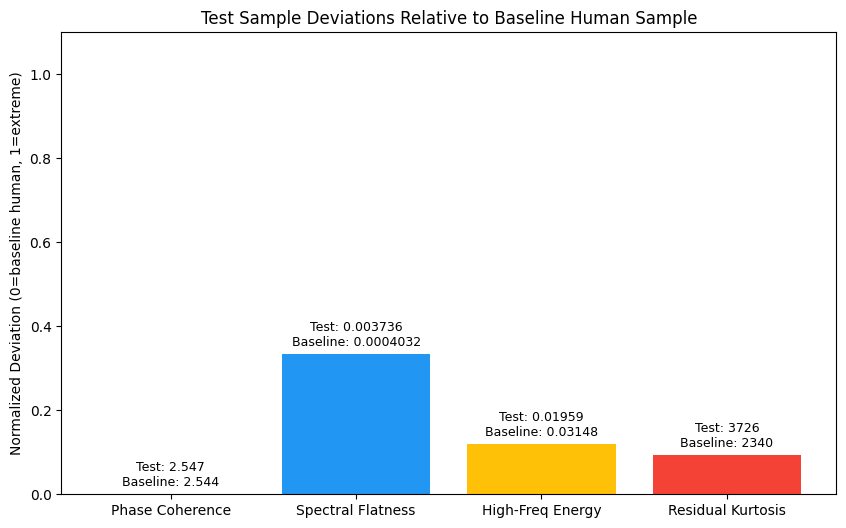

In [9]:
import matplotlib.pyplot as plt

# Metric names
metrics = ["Phase Coherence", "Spectral Flatness", "High-Freq Energy", "Residual Kurtosis"]

# Baseline human values
baseline_values = [baseline_phase_coherence, baseline_flatness, baseline_high_energy_ratio, baseline_residual_kurtosis]

# Test sample values
test_values = [test_phase_coherence, test_flatness, test_high_energy_ratio, test_residual_kurtosis]

# Calculate normalized deviations (percentage of typical human range)
normalized_devs = [phase_dev, flatness_dev, highfreq_dev, kurtosis_dev]

# Create figure
plt.figure(figsize=(10,6))
bars = plt.bar(metrics, normalized_devs, color=['#4CAF50','#2196F3','#FFC107','#F44336'])

# Add baseline vs test value annotations
for i, bar in enumerate(bars):
    plt.text(i, bar.get_height() + 0.02, f"Test: {test_values[i]:.4g}\nBaseline: {baseline_values[i]:.4g}",
             ha='center', fontsize=9)

plt.ylim(0,1.1)
plt.ylabel("Normalized Deviation (0=baseline human, 1=extreme)")
plt.title("Test Sample Deviations Relative to Baseline Human Sample")
plt.show()

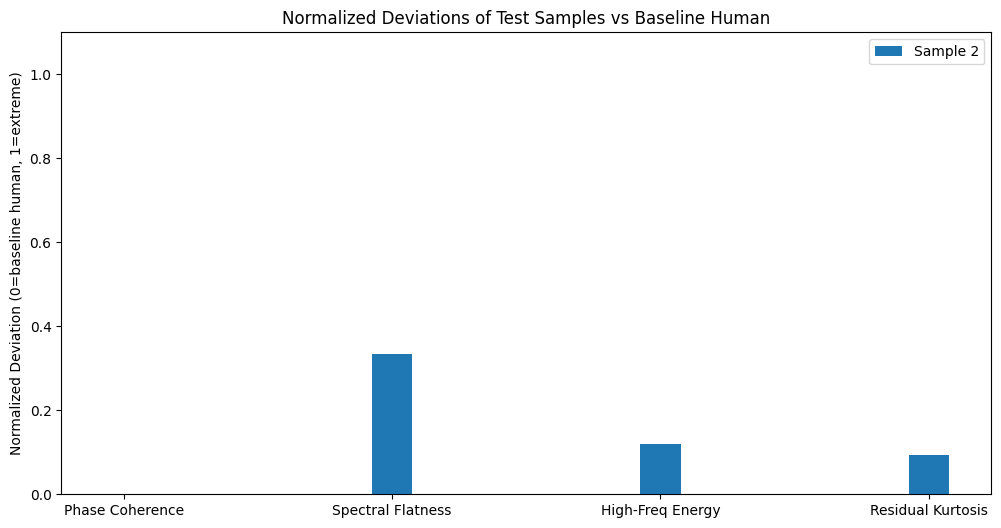

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Define multiple test samples (update paths as needed)
test_samples = {
    "Sample 2": "/content/sample_2.mp3",
    # You can add more samples here
    # "Sample 3": "/content/sample_3.mp3",
}

# Store results
sample_names = []
normalized_deviations = []

# Expected human ranges for normalization
human_ranges = {
    "phase": 5.0,
    "flatness": 0.01,
    "highfreq": 0.1,
    "kurtosis": 15000.0
}

# Function to compute metrics
def compute_metrics(signal, sr):
    stft = librosa.stft(signal, n_fft=2048, hop_length=512)
    phase = np.angle(stft)
    phase_diff = np.diff(phase, axis=1)
    phase_coherence = np.mean(np.abs(np.std(phase_diff, axis=1)))

    flatness = np.mean(librosa.feature.spectral_flatness(y=signal))

    fft = np.fft.rfft(signal)
    freqs = np.fft.rfftfreq(len(signal), d=1/sr)
    high_energy_ratio = np.sum(np.abs(fft[freqs>8000])) / np.sum(np.abs(fft))

    mel_spec = librosa.feature.melspectrogram(y=signal, sr=sr, n_mels=128)
    mel_db = librosa.power_to_db(mel_spec)
    mfcc = librosa.feature.mfcc(S=mel_db, n_mfcc=20)
    reconstructed = librosa.feature.inverse.mfcc_to_mel(mfcc, n_mels=128)
    residual = mel_spec - reconstructed
    residual_kurtosis = kurtosis(residual.flatten())

    return phase_coherence, flatness, high_energy_ratio, residual_kurtosis

# Function to compute normalized deviation
def normalized_dev(baseline_metrics, test_metrics):
    return [
        min(abs(test - base)/human_ranges[key], 1.0)
        for test, base, key in zip(test_metrics, baseline_metrics, ["phase", "flatness", "highfreq", "kurtosis"])
    ]

# Baseline metrics
baseline_metrics = compute_metrics(baseline_signal, baseline_sr)

# Process each test sample
for name, path in test_samples.items():
    signal, sr = librosa.load(path, sr=None)
    metrics = compute_metrics(signal, sr)
    dev = normalized_dev(baseline_metrics, metrics)
    sample_names.append(name)
    normalized_deviations.append(dev)

# Plot
metrics_labels = ["Phase Coherence", "Spectral Flatness", "High-Freq Energy", "Residual Kurtosis"]
x = np.arange(len(metrics_labels))
width = 0.15

fig, ax = plt.subplots(figsize=(12,6))

for i, dev in enumerate(normalized_deviations):
    ax.bar(x + i*width, dev, width, label=sample_names[i])

ax.set_xticks(x + width*(len(test_samples)-1)/2)
ax.set_xticklabels(metrics_labels)
ax.set_ylabel("Normalized Deviation (0=baseline human, 1=extreme)")
ax.set_title("Normalized Deviations of Test Samples vs Baseline Human")
ax.legend()
plt.ylim(0, 1.1)
plt.show()